# E-Commerce Sales & Customer Analytics

## Business Problem

The objective of this project is to analyze e-commerce transaction data to identify revenue trends, customer purchasing behavior, top-performing products, and geographic sales patterns. The insights generated will help support data-driven business decisions and business growth.

## Data Understanding

This dataset contains e-commerce transaction records including invoice details, product information, customer information, quantities purchased, unit prices, and customer countries. The dataset will be analyzed to uncover sales trends, customer behavior, and product performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import os
os.listdir("../Dataset")

['.ipynb_checkpoints', 'cleaned_ecommerce_data.csv', 'data.csv']

In [3]:
df = pd.read_csv("../Dataset/data.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Quality Assessment

### Key Findings

- Dataset contains **541,909** transactions and **8** columns.
- CustomerID contains **135,080** missing values.
- Description contains **1,454** missing values.
- Quantity includes negative values, indicating returns or cancellations.
- UnitPrice includes negative values, indicating refunds or adjustments.



In [9]:
duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 5268


## Data Cleaning & Missing Value Handling


To ensure accurate business insights, the dataset was cleaned before analysis.

- Removed rows with missing product descriptions.
- Removed rows with missing customer IDs.
- Removed cancelled/returned orders (negative quantity values).
- Removed records with non-positive unit prices.
- Removed duplicate transactions.
- Created a Revenue feature:   Revenue = Quantity × UnitPrice

After cleaning, the dataset contained only valid customer purchases suitable for sales and customer analytics.

In [10]:
df_clean = df.copy()

In [11]:
df_clean = df_clean.dropna(subset=['Description'])

In [12]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [13]:
df_clean = df_clean[df_clean['Quantity'] > 0]

In [14]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [15]:
df_clean = df_clean.drop_duplicates()

In [16]:
print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (541909, 8)
Cleaned Shape: (392692, 8)


In [17]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [18]:
df_clean[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Feature Engineering

Additional features are created from transaction dates to support time-based analysis and business insights.

In [19]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [20]:
df_clean['Year'] = df_clean['InvoiceDate'].dt.year

In [21]:
df_clean['Month'] = df_clean['InvoiceDate'].dt.month_name()

In [22]:
df_clean['Month_Num'] = df_clean['InvoiceDate'].dt.month

In [23]:
df_clean['Quarter'] = df_clean['InvoiceDate'].dt.quarter

In [24]:
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()

In [25]:
df_clean[['InvoiceDate','Year','Month','Month_Num','Quarter','DayOfWeek']].head()

,InvoiceDate,Year,Month,Month_Num,Quarter,DayOfWeek
0,2010-12-01 08:26:00,2010,December,12,4,Wednesday
1,2010-12-01 08:26:00,2010,December,12,4,Wednesday
2,2010-12-01 08:26:00,2010,December,12,4,Wednesday
3,2010-12-01 08:26:00,2010,December,12,4,Wednesday
4,2010-12-01 08:26:00,2010,December,12,4,Wednesday


## Key Performance Indicators (KPIs)

In [26]:
total_revenue = df_clean['Revenue'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [27]:
total_orders = df_clean['InvoiceNo'].nunique()
print("Total Orders:", total_orders)

Total Orders: 18532


In [28]:
total_customers = df_clean['CustomerID'].nunique()
print("Total Customers:", total_customers)

Total Customers: 4338


In [29]:
aov = total_revenue / total_orders
print(f"Average Order Value: £{aov:,.2f}")

Average Order Value: £479.56


## Revenue Trend Analysis

In [30]:
monthly_revenue = df_clean.groupby(
    ['Year','Month_Num','Month']
)['Revenue'].sum().reset_index()

monthly_revenue.head()

,Year,Month_Num,Month,Revenue
0,2010,12,December,570422.730
1,2011,1,January,568101.310
2,2011,2,February,446084.920
3,2011,3,March,594081.760
4,2011,4,April,468374.331


In [31]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [32]:
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum().reset_index()

monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)

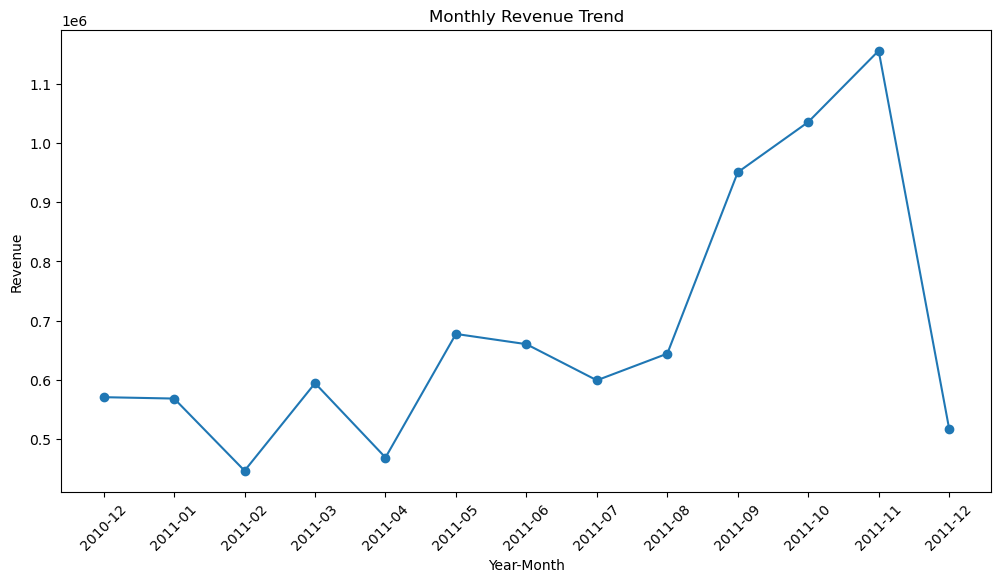

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_revenue['YearMonth'],
    monthly_revenue['Revenue'],
    marker='o'
)

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.show()

In [34]:
monthly_revenue.sort_values(
    by='Revenue',
    ascending=False
).head(5)

,YearMonth,Revenue
11,2011-11,1156205.610
10,2011-10,1035642.450
9,2011-09,950690.202
5,2011-05,677355.150
6,2011-06,660046.050


### Revenue Trend Insights

- Revenue increased significantly during Q4 2011, with November generating the highest monthly revenue (£1.16M).
- The growth appears to be driven by seasonal demand associated with holiday shopping and festive purchases.
- Home décor and gift-related products dominated top-performing product categories during this period.
- Increased purchasing activity from high-value customers may have further contributed to revenue growth.

## Product Performance Analysis

In [35]:
top_products = (
    df_clean.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

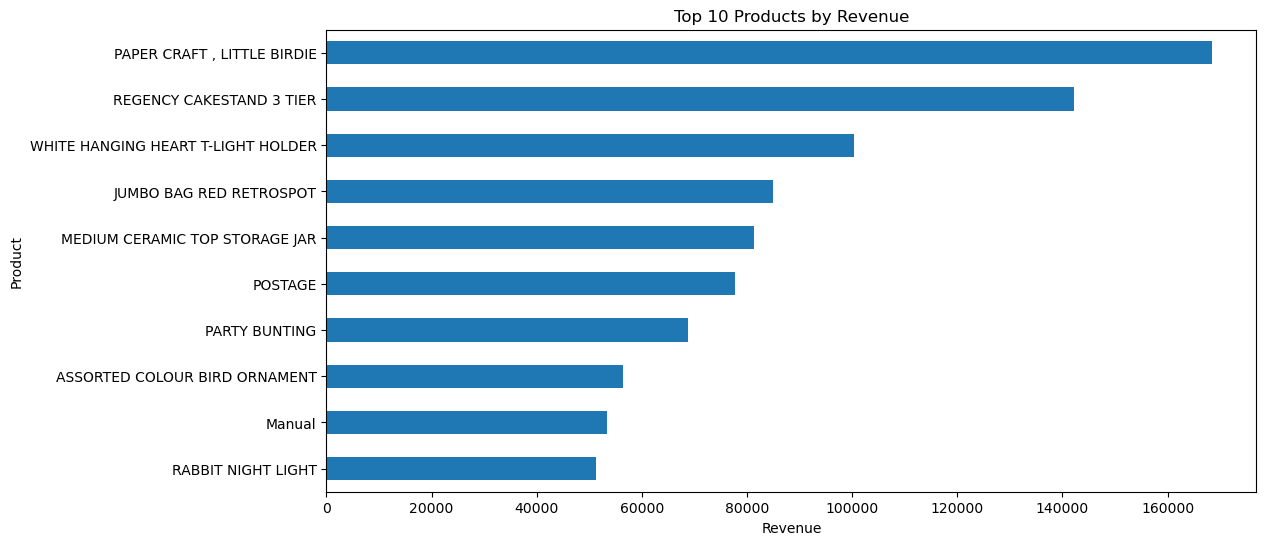

In [36]:
plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product')
plt.show()

### Product Performance Insights

- **PAPER CRAFT, LITTLE BIRDIE** generated the highest revenue among all products.
- **REGENCY CAKESTAND 3 TIER** and **WHITE HANGING HEART T-LIGHT HOLDER** were also major revenue contributors.
- The top 10 products contributed a significant share of overall business revenue.
- Home décor, gift items, and storage products appear to be the strongest-performing product categories.

In [37]:
top_quantity = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

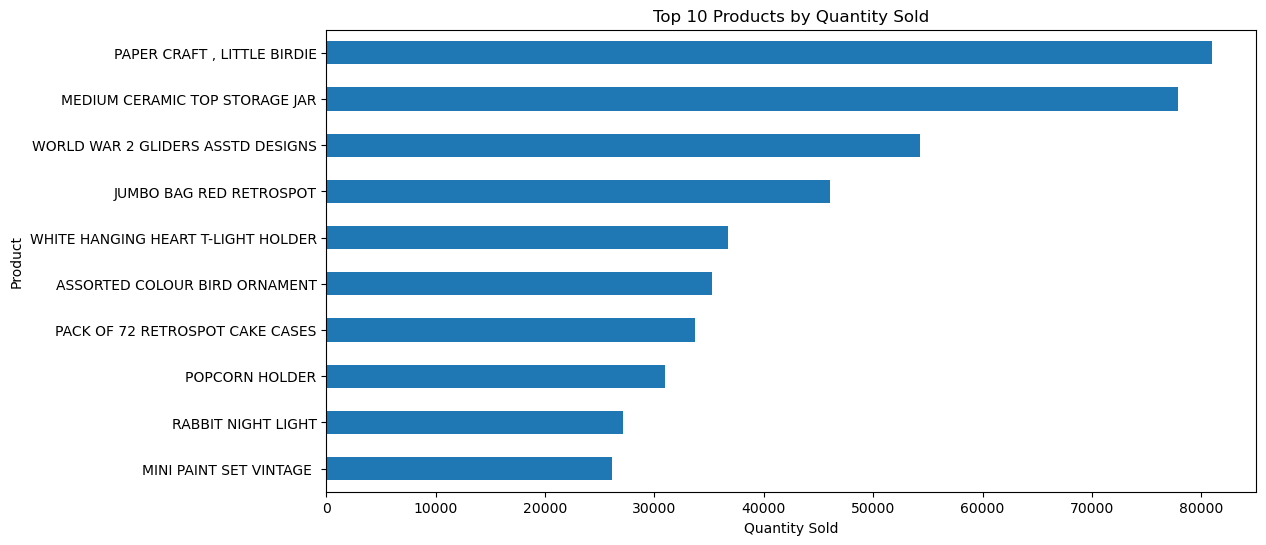

In [38]:
plt.figure(figsize=(12,6))

top_quantity.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Product')
plt.show()

## Customer Analysis

In [39]:
top_customers = (
    df_clean.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [40]:
top_customer = top_customers.index[0]
print(top_customer)

14646.0


In [41]:
customer_products = (
    df_clean[df_clean['CustomerID'] == top_customer]
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

customer_products

Description
RABBIT NIGHT LIGHT                     4801
SPACEBOY LUNCH BOX                     4492
PACK OF 72 RETROSPOT CAKE CASES        4104
DOLLY GIRL LUNCH BOX                   4096
ROUND SNACK BOXES SET OF4 WOODLAND     3120
RED TOADSTOOL LED NIGHT LIGHT          2376
WOODLAND CHARLOTTE BAG                 2300
RED RETROSPOT CHARLOTTE BAG            2100
5 HOOK HANGER RED MAGIC TOADSTOOL      2016
JUMBO BAG RED RETROSPOT                2000
GINGHAM HEART DECORATION               1872
SPACEBOY BIRTHDAY CARD                 1872
MINI PAINT SET VINTAGE                 1728
PLASTERS IN TIN SPACEBOY               1632
ROUND SNACK BOXES SET OF 4 FRUITS      1584
PLASTERS IN TIN WOODLAND ANIMALS       1536
JUMBO BAG WOODLAND ANIMALS             1500
PACK OF 60 SPACEBOY CAKE CASES         1440
CHARLOTTE BAG PINK POLKADOT            1400
PACK OF 60 MUSHROOM CAKE CASES         1320
Name: Quantity, dtype: int64

In [42]:
top_customer = top_customers.index[0]

top_customer_revenue = top_customers.iloc[0]

print(f"Top Customer ID: {int(top_customer)}")
print(f"Revenue Generated: £{top_customer_revenue:,.2f}")

Top Customer ID: 14646
Revenue Generated: £280,206.02


In [43]:
customer_contribution = (top_customer_revenue / total_revenue) * 100

print(f"Contribution to Total Revenue: {customer_contribution:.2f}%")

Contribution to Total Revenue: 3.15%


### Customer Insights

- Customer with **CustomerID: 14646** was the highest-value customer.
- The customer generated **£280,206.02** in total revenue.
- The customer contributed **3.15%** of overall company revenue.
- Understanding the purchasing behavior of top customers can help design targeted retention and loyalty programs.

In [44]:
top_customer = top_customers.index[0]

customer_products = (
    df_clean[df_clean['CustomerID'] == top_customer]
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_products

Description
RABBIT NIGHT LIGHT                     9568.48
ROUND SNACK BOXES SET OF4 WOODLAND     7956.00
SPACEBOY LUNCH BOX                     7415.40
DOLLY GIRL LUNCH BOX                   6758.40
ROUND SNACK BOXES SET OF 4 FRUITS      4039.20
JUMBO BAG RED RETROSPOT                3468.00
RED TOADSTOOL LED NIGHT LIGHT          3459.60
REGENCY CAKESTAND 3 TIER               3153.60
5 HOOK HANGER RED MAGIC TOADSTOOL      2923.20
JUMBO BAG WOODLAND ANIMALS             2629.00
Name: Revenue, dtype: float64

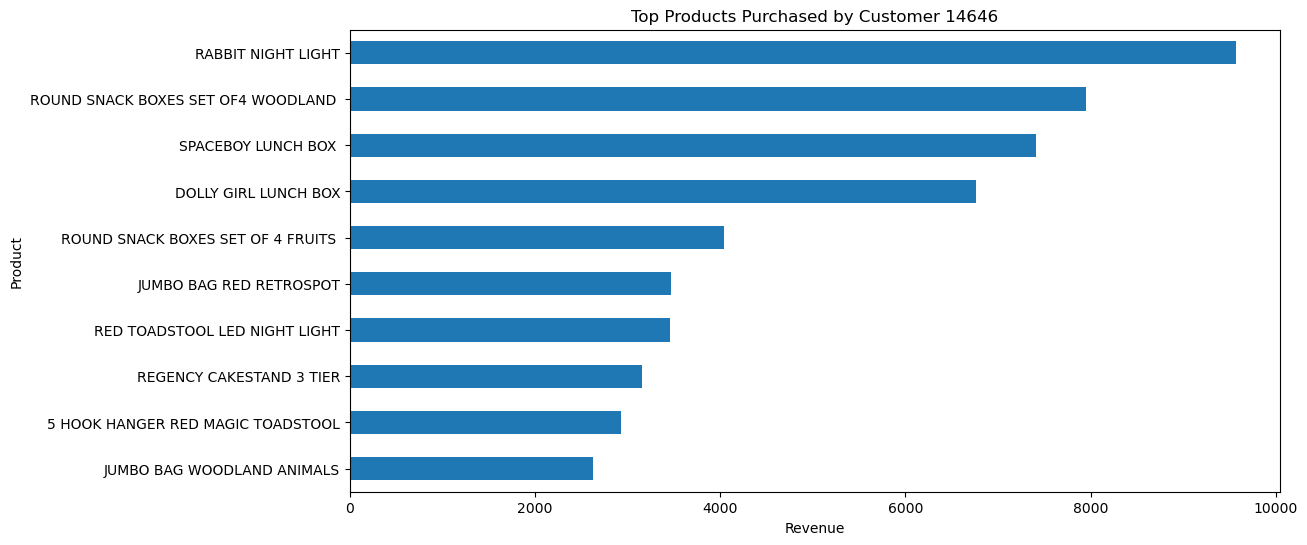

In [45]:
plt.figure(figsize=(12,6))

customer_products.sort_values().plot(kind='barh')

plt.title(f'Top Products Purchased by Customer {int(top_customer)}')
plt.xlabel('Revenue')
plt.ylabel('Product')

plt.show()

### Purchasing Behavior of Top Customer

- The **highest-value** customer primarily purchased products related to **home décor and gift items**.
- Several purchases were repeated across multiple transactions, indicating strong product preference.
- Understanding these preferences can help create personalized promotions and customer retention strategies.

## Country Analysis

In [46]:
country_revenue = (
    df_clean.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

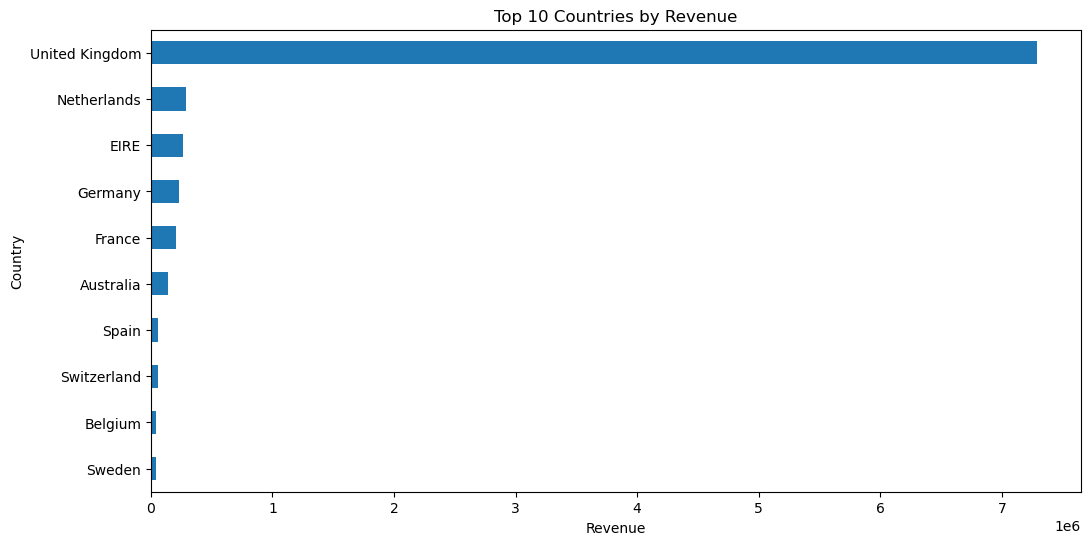

In [47]:
plt.figure(figsize=(12,6))

country_revenue.sort_values().plot(kind='barh')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Country')

plt.show()

### Country Insights

- The **United Kingdom** generated the **highest** revenue among all countries.
- Several European countries contributed significantly to overall sales.
- Revenue concentration in a few countries suggests opportunities for geographic expansion and targeted marketing campaigns.

# Executive Summary

This section summarizes the key findings from the analysis.

In [48]:
print(f"Total Revenue: £{total_revenue:,.2f}")
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print(f"Average Order Value: £{aov:,.2f}")

Total Revenue: £8,887,208.89
Total Orders: 18532
Total Customers: 4338
Average Order Value: £479.56


## Key Findings

- Total revenue generated was **£8.89 million**.
- A total of **18,532 orders** were processed.
- **4,338 customers** contributed to overall revenue.
- Average Order Value was **£479.56**.
- **November 2011** generated the highest monthly revenue.
- **PAPER CRAFT, LITTLE BIRDIE** was the highest revenue-generating product.
- Customer **14646** was the highest-value customer.
- **The United Kingdom** generated the highest revenue among all countries.

## Recommendations

1. Increase inventory for top-performing products such as PAPER CRAFT, LITTLE BIRDIE.
2. Launch loyalty programs for high-value customers like Customer 14646 and similar customer segments.
3. Focus marketing efforts during Q4, as September-November generated the highest revenue.
4. Explore opportunities in high-performing international markets beyond the United Kingdom.
5. Monitor customer acquisition trends closely, as revenue growth appears strongly linked to increases in active customers and orders.

In [49]:
df_clean.to_csv("../Dataset/cleaned_ecommerce_data.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
